In [19]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects, aberration, equatorial2galactic, galactic2equatorial
import os
import numpy as np
import referenceFrames as rf
import matplotlib.pyplot as plt
from math import radians

In [20]:
sim = Simulation("AbsoluteStellarAberration")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

# We want to cover one year of observations, with one exposure every 5 days

numExposures = 365 * 24 * 60 * 60 // 25
sim["ObservingParameters/NumExposures"] = 1
deltaNumExposures = 24 * 60 * 60 // 25 * 5


starCatalogFilename = os.environ["PLATO_WORKDIR"] + "generatedFromPixelCoordinates.starcat"
dim = 6
sim.createStarCatalogFileFromPixelCoordinates(np.array([100]), np.array([100]), np.array([12.5]), np.array([1]), starCatalogFilename)
sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

sim["SubField/NumRows"] = dim
sim["SubField/NumColumns"] = dim
sim["SubField/ZeroPointRow"] = 100 - dim // 2
sim["SubField/ZeroPointColumn"] = 100 - dim // 2

# Enable absolute stellar aberration

sim["Camera/IncludeAberrationCorrection"] = "yes"
sim["Camera/AberrationCorrection/Type"] = "absolute"

In [21]:
outputRa = np.array([])
outputDec = np.array([])

raPlatform = radians(sim["ObservingParameters/RApointing"])
decPlatform = radians(sim["ObservingParameters/DecPointing"])
solarPanelOrientation = radians(sim["Platform/SolarPanelOrientation"])
tiltAngle = radians(sim["Telescope/TiltAngle"])
azimuthAngle = radians(sim["Telescope/AzimuthAngle"])
focalPlaneAngle = radians(sim["Camera/FocalPlaneOrientation/ConstantValue"])
focalLength = sim["Camera/FocalLength/ConstantValue"] * 1000

for beginExposure in range(0, numExposures, deltaNumExposures):
    
    sim["ObservingParameters/BeginExposureNr"] = beginExposure
    output = sim.run(removeOutputFile = True)
    
    ([xFP], [yFP]) = output.getStarCoordinates(beginExposure)[3:5]
    ra, dec = rf.focalPlaneToSkyCoordinates(xFP, yFP, raPlatform, decPlatform, solarPanelOrientation, tiltAngle, azimuthAngle, focalPlaneAngle, focalLength)
    outputRa = np.append(outputRa, ra)
    outputDec = np.append(outputDec, dec)

outputRa = np.rad2deg(outputRa)
outputDec = np.rad2deg(outputDec)

In [24]:
([inputRa], [inputDec]) = (output.getStarCatalog()[1:3])

Text(0, 0.5, '$\\delta - \\delta_0$ [arcsec]')

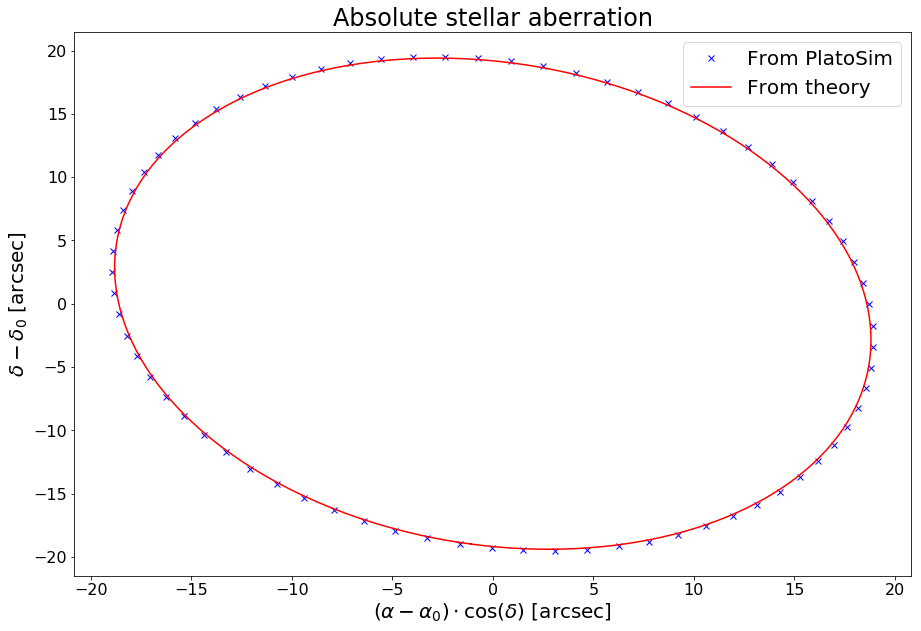

In [25]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.plot((outputRa - inputRa) * 3600 * np.cos(np.deg2rad(outputDec)), (outputDec - inputDec) * 3600, "bx", label = "From PlatoSim")



########
# Theory
########

lambdaSun = np.linspace(0, 2 * np.pi, 365)
raStar  = np.zeros(365)
decStar = np.zeros(365)

for n in range(len(lambdaSun)):
    
    lonStar, latStar = equatorial2galactic(inputRa, inputDec)
    lambdaStar, betaStar = aberration(lonStar, latStar, lambdaSun[n])
    newRa, newDec = galactic2equatorial(lambdaStar, betaStar)
    raStar[n], decStar[n] = newRa, newDec

plt.plot((raStar - inputRa) * 3600 * np.cos(np.deg2rad(decStar)), (decStar - inputDec) * 3600, "r", label = "From theory")



########
# Layout
########

plt.title("Absolute stellar aberration", fontsize = 24)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("$(\\alpha - \\alpha_0) \cdot \\cos{(\\delta)}$ [arcsec]", fontsize = 20)
plt.ylabel("$\\delta - \\delta_0$ [arcsec]", fontsize = 20)